# BROAD-NESS for Python pipline

## Get the data and explore them 


Your data are: 3559 sources, over 776 time points, 5 conditions: ['M1', 'NT1', 'NT2', 'NT3', 'NT4']
--------------------------------------------
Computing PCA on the mean over conditions :
--------------------------------------------


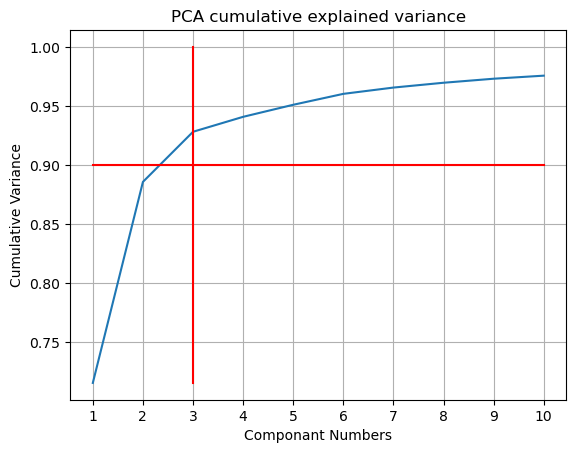

3 componant(s) account for 92.81 variance explained:
Componant 1 : 71.54 %
Componant 2 : 17.03 %
Componant 3 : 4.24 %
3 componant(s) will be used by default for the following analysis. Please change manually if needed.


In [1]:
from utils import load_data, data_overview
data_path = '/Users/barbaragrosjean/Documents/MIB/broadness/datasets/Data_Example.mat'
conditions={'M1':0, 'NT1':1, 'NT2':2, 'NT3':3, 'NT4':4}
data= load_data(data_path)

nb_compo = data_overview(data, conditions=conditions)

## Network estimation

In [2]:
from network_estimation import NetworkEstimator

estimator = NetworkEstimator(n_components=5, method="pca", conditions=conditions)

# Fit the estimator 
estimator.fit(data)

# You can threshold the componants 
#thr_compo = estimator.threshold_components()

# Once the estimator is fit you can access the componants (nb_PC, nb_sources)
print(f'The commponants are : {estimator.components_.shape[0]} PCs, {estimator.components_.shape[1]} sources')

The commponants are : 5 PCs, 3559 sources


In [3]:
# Get the results 
result = estimator.fit_transform(data)

# With the results you can access to :
#result.components
#result.explained_variance
#result.timecourses["M1"] # Select the right condition that you are interested in!
#result.reconstructed_activity["M1"]

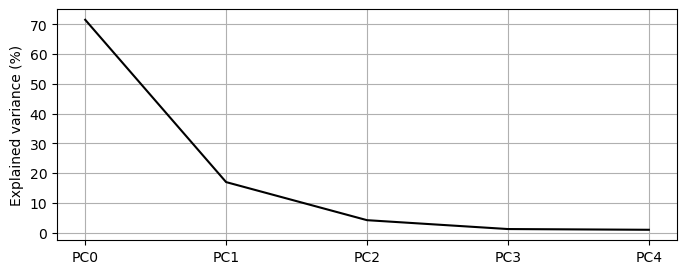

In [4]:
# Get here the plot of the variance
result.plot_variance()

In [5]:
# You can transform componant into a nifti image
#img = result.get_nifti_component(1, save=True)

In [6]:
# Once that you have the result you can plot them or interact
#fig, axs = result.plot_components(n_compo=1) 
#result.plot_components_interactive(n_compo=1) 

In [7]:
# Then access to the time course of your componants
#result.plot_timecourses(groupby='components', condition_to_plot=['M1', 'NT1'], time_course_to_plot=[1, 2], save=False)

In [8]:
# Finally you can run statistical analysis on the componants
from utils import compute_significant_pcs
#significant_pcs = compute_significant_pcs(data[:, :, 1], result.explained_variance, permutations_num=10, randomization=3, summary=True)

## Gradiant Analysis

--------------------------------------------
kmeans on 2 PCs
--------------------------------------------
Selecting the right number of componants for K-means ...
With 4 cluster(s) we have a silhouette score of 0.4815153479576111


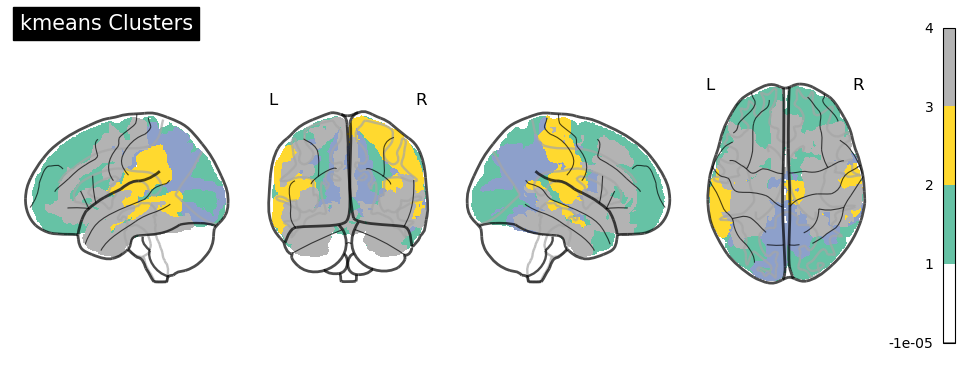

In [9]:
from gradiant import clustering

res= clustering(result.components[:2, :])
res.plot_clusters_brain()


## RQA analysis

In [10]:
from rqa import compute_rqa
import numpy as np

res = compute_rqa(result.timecourses, time=np.arange(0, len(result.timecourses['M1'])), conditions=conditions, nb_compo=1)

--------------------------------------------
Phase Space RQA on pca with 1 PCs
--------------------------------------------
Condition :  M1
Condition :  NT1
Condition :  NT2
Condition :  NT3
Condition :  NT4


In [11]:
res.animate_phase_space('M1') # DOESN'T DO WHAT I WANT TODO